# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2627s 15us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

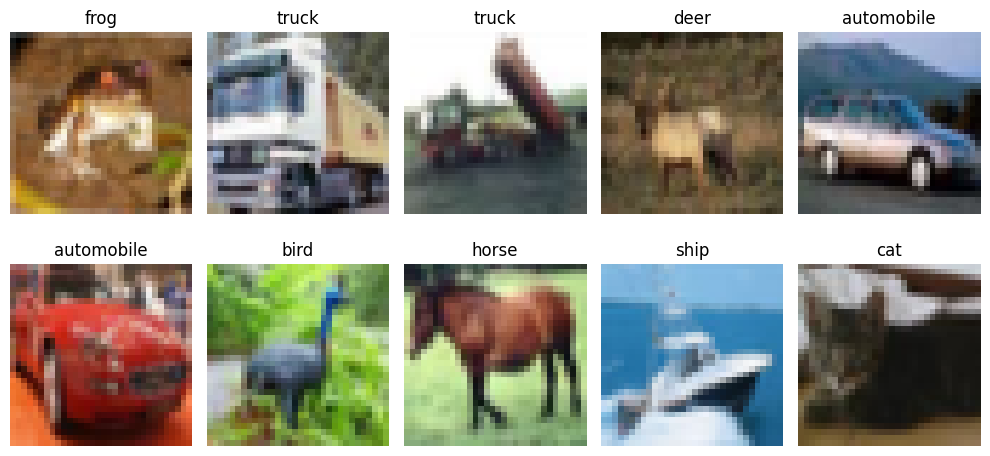

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.2724 - loss: 1.9896 - val_accuracy: 0.3340 - val_loss: 1.8569
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3240 - loss: 1.8575 - val_accuracy: 0.3566 - val_loss: 1.7830
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.3430 - loss: 1.7979 - val_accuracy: 0.4022 - val_loss: 1.7193
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.3541 - loss: 1.7712 - val_accuracy: 0.3898 - val_loss: 1.7289
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3626 - loss: 1.7454 - val_accuracy: 0.4014 - val_loss: 1.7006
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.3722 - loss: 1.7288 - val_accuracy: 0.4044 - val_loss: 1.6846
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3804 - loss: 1.7093 - val_accuracy: 0.4096 - val_loss: 1.6803
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.3840 - loss: 1.6928 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4252 - loss: 1.6280
ANN Test Accuracy: 0.4251999855041504


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 76ms/step - accuracy: 0.4743 - loss: 1.4736 - val_accuracy: 0.5252 - val_loss: 1.3011
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 73ms/step - accuracy: 0.6153 - loss: 1.1068 - val_accuracy: 0.6146 - val_loss: 1.0987
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 74ms/step - accuracy: 0.6738 - loss: 0.9337 - val_accuracy: 0.6366 - val_loss: 1.0525
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 75ms/step - accuracy: 0.7162 - loss: 0.8167 - val_accuracy: 0.6524 - val_loss: 1.0221
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 77ms/step - accuracy: 0.7440 - loss: 0.7258 - val_accuracy: 0.6484 - val_loss: 1.1344
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 72ms/step - accuracy: 0.7759 - loss: 0.6436 - val_accuracy: 0.6980 - val_loss: 0.9255
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 81ms/step - accuracy: 0.7996 - loss: 0.5717 - val_accuracy: 0.6988 - val_loss: 0.9342
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 61s 87ms/step - accuracy: 0.8167 - loss: 0.5126 - 

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7253 - loss: 0.9504
CNN Test Accuracy: 0.7253000140190125


## 📈 Compare Learning Curves

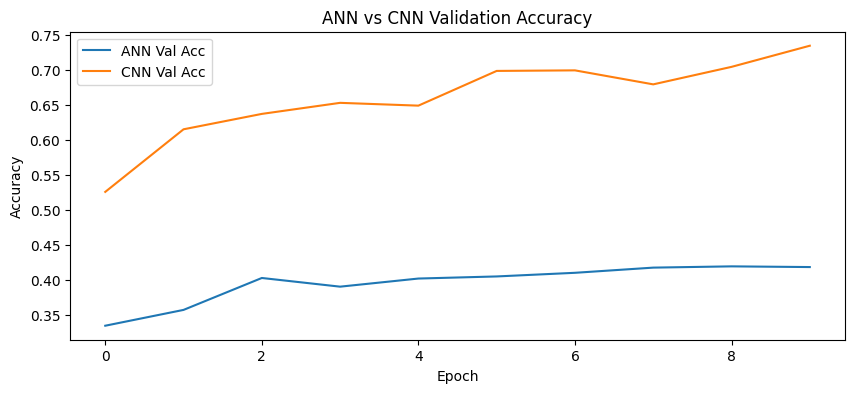

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4252
1,CNN,0.7253


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

In [12]:
i_ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

i_ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

i_ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,837,066 (14.64 MB)

 Trainable params: 3,837,066 (14.64 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

i_ann_history = i_ann_model.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

improved_ann_test_loss, improved_ann_test_acc = i_ann_model.evaluate(x_test_flat, y_test)
print("Improved ANN Test Accuracy:", improved_ann_test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 53ms/step - accuracy: 0.2428 - loss: 2.0333 - val_accuracy: 0.3234 - val_loss: 1.8520
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 51ms/step - accuracy: 0.3122 - loss: 1.8769 - val_accuracy: 0.3426 - val_loss: 1.8306
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.3311 - loss: 1.8219 - val_accuracy: 0.3488 - val_loss: 1.7851
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 52ms/step - accuracy: 0.3453 - loss: 1.7939 - val_accuracy: 0.3912 - val_loss: 1.7369
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - accuracy: 0.3554 - loss: 1.7648 - val_accuracy: 0.3834 - val_loss: 1.7261
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 49ms/step - accuracy: 0.3654 - loss: 1.7440 - val_accuracy: 0.3942 - val_loss: 1.6767
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - accuracy: 0.3741 - loss: 1.7252 - val_accuracy: 0.3948 - val_loss: 1.6860
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.3783 - loss: 1.7114 - 

In [14]:
i_cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

i_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

i_cnn_history = i_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

i_cnn_test_loss, i_cnn_test_acc = i_cnn_model.evaluate(x_test_norm, y_test)
print("Improved CNN Test Accuracy:", i_cnn_test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 175s 244ms/step - accuracy: 0.4879 - loss: 1.4471 - val_accuracy: 0.5974 - val_loss: 1.1461
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 196s 236ms/step - accuracy: 0.6468 - loss: 1.0106 - val_accuracy: 0.6978 - val_loss: 0.8642
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 167s 236ms/step - accuracy: 0.7080 - loss: 0.8347 - val_accuracy: 0.7102 - val_loss: 0.8570
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 201s 235ms/step - accuracy: 0.7536 - loss: 0.7123 - val_accuracy: 0.7280 - val_loss: 0.8169
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 205s 239ms/step - accuracy: 0.7791 - loss: 0.6306 - val_accuracy: 0.7592 - val_loss: 0.7075
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 163s 231ms/step - accuracy: 0.8075 - loss: 0.5549 - val_accuracy: 0.7590 - val_loss: 0.7142
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 164s 234ms/step - accuracy: 0.8280 - loss: 0.4898 - val_accuracy: 0.7916 - val_loss: 0.6402
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 204s 236ms/step - accuracy: 0.8469 -

In [15]:
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 60ms/step - accuracy: 0.3692 - loss: 1.7234 - val_accuracy: 0.4854 - val_loss: 1.4028
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.4673 - loss: 1.4777 - val_accuracy: 0.5148 - val_loss: 1.3572
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.5086 - loss: 1.3792 - val_accuracy: 0.5734 - val_loss: 1.2107
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4940 - loss: 1.4067
Augmented CNN Test Accuracy: 0.49399998784065247


In [16]:
full_comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "Improved ANN", "Improved CNN", "Augmented CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, improved_ann_test_acc,
                       i_cnn_test_acc, aug_test_acc]
}).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)

full_comparison

,Model,Test Accuracy
0,Improved CNN,0.7869
1,CNN,0.7253
2,Augmented CNN,0.4940
3,Improved ANN,0.4365
4,ANN,0.4252


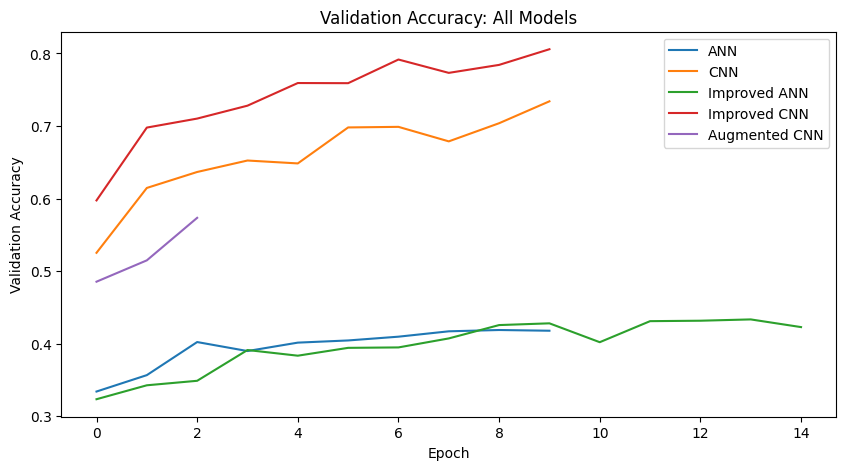

In [18]:
plt.figure(figsize=(10,5))
plt.plot(ann_history.history['val_accuracy'], label='ANN')
plt.plot(cnn_history.history['val_accuracy'], label='CNN')
plt.plot(i_ann_history.history['val_accuracy'], label='Improved ANN')
plt.plot(i_cnn_history.history['val_accuracy'], label='Improved CNN')
plt.plot(aug_history.history['val_accuracy'], label='Augmented CNN')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy: All Models")
plt.legend()
plt.show()

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**